<a href="https://colab.research.google.com/github/S-idd/GENAINPTEL/blob/main/PE2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets,layers,models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay

In [2]:
(x_train,y_train),(x_test,y_test)=datasets.cifar10.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

class_names = [
    'airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck'
]

print("Training Data Set Shape : ",x_train.shape)
print("Training Data Set Labels : ",y_train.shape)
print("Testing Data Set Shape : ",x_test.shape)
print("Testing Data Set Labels : ",y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3481s 20us/step
Training Data Set Shape :  (50000, 32, 32, 3)
Training Data Set Labels :  (50000, 1)
Testing Data Set Shape :  (10000, 32, 32, 3)
Testing Data Set Labels :  (10000, 1)


Define Model 1

In [6]:
def Create_CNN1():
   model = tf.keras.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),

    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='softmax')

   ])

   return model ;


Define Model 2

In [7]:
def Create_CNN2():
   model = tf.keras.Sequential([
    layers.Conv2D(32,(3,3),input_shape=(32,32,3)),
    layers.Activation('relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),

    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='softmax')

   ])

   return model ;

Define Model 3

In [8]:
def Create_CNN3():
   model = tf.keras.Sequential([
    layers.Conv2D(32,(3,3),input_shape=(32,32,3)),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),

    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10,activation='softmax')

   ])

   return model ;

Build Ensemble Model

In [9]:
Model1 = Create_CNN1() ;
Model2 = Create_CNN2() ;
Model3 = Create_CNN3() ;

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
for Model in [Model1,Model2,Model3] :

  Model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])



In [14]:
history1 = Model1.fit(x_train,y_train,epochs=5,validation_data=(x_test,y_test),validation_split=0.2,batch_size=64)

history2 = Model2.fit(x_train,y_train,epochs=5,validation_data=(x_test,y_test),validation_split=0.2,batch_size=64)

history3 = Model3.fit(x_train,y_train,epochs=5,validation_data=(x_test,y_test),validation_split=0.2,batch_size=64)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 67s 86ms/step - accuracy: 0.7976 - loss: 0.5782 - val_accuracy: 0.7035 - val_loss: 0.9220
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 86ms/step - accuracy: 0.8060 - loss: 0.5500 - val_accuracy: 0.7176 - val_loss: 0.8620
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 66s 84ms/step - accuracy: 0.8174 - loss: 0.5187 - val_accuracy: 0.7208 - val_loss: 0.8690
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 84ms/step - accuracy: 0.8296 - loss: 0.4847 - val_accuracy: 0.7159 - val_loss: 0.8870
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 85ms/step - accuracy: 0.8423 - loss: 0.4527 - val_accuracy: 0.7086 - val_loss: 0.9405
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 100s 128ms/step - accuracy: 0.6732 - loss: 0.9351 - val_accuracy: 0.5645 - val_loss: 1.2706
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 102s 131ms/step - accuracy: 0.7267 - loss: 0.7757 - val_accuracy: 0.6513 - val_loss: 1.0039
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 101s 129ms/step - accuracy: 0.7672 - loss: 0.6666 - va

In [15]:
pred1 = Model1.predict(x_test)

pred2 = Model2.predict(x_test)

pred3 = Model3.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


In [16]:
ensemble_pred = (
    pred1 + pred2 + pred3
) / 3


In [17]:
y_pred = np.argmax(ensemble_pred,axis=1)

In [18]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,y_pred)
print("Accuracy : ",accuracy)


Accuracy :  0.75


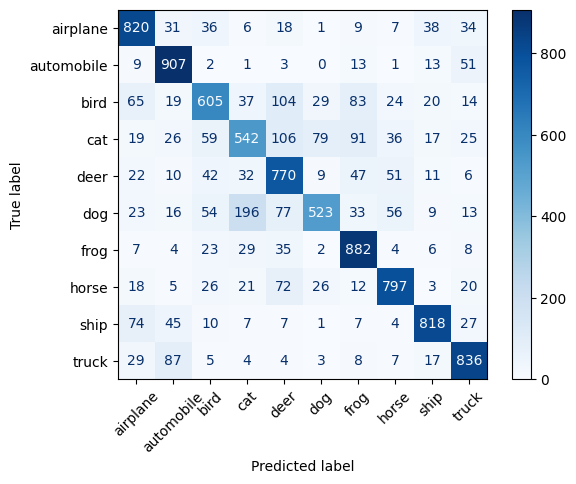

In [20]:
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay

cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=class_names)
disp.plot(cmap=plt.cm.Blues,xticks_rotation=45)
plt.show()